In [17]:
print('Begin')
import os
import sys
from datetime import datetime
import scanpy as sc
import logging

import anndata

# Optional: suppress scanpy verbosity
sc.settings.verbosity = 1
logging.basicConfig(level=logging.INFO)

# If needed, insert the path to scVIDR
dev_path = os.path.abspath('/mnt/scratch/bowmand8/scVIDR/scvidr_sandbox/scVIDR')
if dev_path not in sys.path:
    sys.path.insert(0, dev_path)
print(f"Added to sys.path: {dev_path}")

from vidr import VIDR, normalize_data, prepare_data


#Import important modules

import scgen as scg
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import gseapy as gp
from scipy import stats
from scipy import linalg
from scipy import spatial
from anndata import AnnData
from scipy import sparse
from statannotations.Annotator import Annotator
from matplotlib import pyplot as plt

#For calculating statistical distance
import geomloss
import pykeops
pykeops.clean_pykeops()          # just in case old build files are still present
pykeops.test_numpy_bindings()    # perform the compilation

import scvi
sc.set_figure_params(dpi = 150)
sc.settings.figdir = "../figures"
sns.set_style("dark")

Begin
Added to sys.path: /mnt/scratch/bowmand8/scVIDR/scvidr_sandbox/scVIDR
[KeOps] /mnt/home/bowmand8/.cache/keops2.2.3/Linux_dev-amd24-h200_5.15.0-126-generic_p3.9.18 has been cleaned.
[KeOps] Generating code for Sum_Reduction reduction (with parameters 1) of formula Sum((a-b)**2) with a=Var(0,3,0), b=Var(1,3,1) ... OK
[pyKeOps] Compiling pykeops cpp d72e8a382b module ... OK
pyKeOps with numpy bindings is working!


In [35]:
# Define your inputs here
h5ad_file_path = '/mnt/research/sbhattacharya_lab/1_DerekBowman/scVIDR/DB_Updates/Full_taPVAT_combined_annotated_with_immune_fibro_ecs_all_genes_unnormalized.h5ad'

# 8W Models

# model_path = '../models/VIDR_August_07_2025_1207_Adipocytes_Brown_8W_F'
# model_path = '../models/VIDR_August_07_2025_1207_Adipocytes_Brown_8W_M'
#model_path = '../models/VIDR_August_07_2025_1152_Adipocytes_Brown_8W_Both'

# 24W Models

# model_path = '../models/VIDR_August_07_2025_1205_Adipocytes_Brown_24W_F'
#model_path = '../models/VIDR_August_07_2025_1204_Adipocytes_Brown_24W_M'
model_path = '../models/VIDR_August_07_2025_1206_Adipocytes_Brown_24W_Both'


In [36]:

celltype_to_predict = 'Adipocytes_Brown' 
condition_to_predict = 'HF'

celltype_column_name = 'celltype'
condition_column_name = 'diet'

control_dose = 'Control'
treated_dose = 'HF'
timeframe_to_consider = '24W'



# Load and normalize
logging.info(f'Loading data file: {h5ad_file_path}')
adata = sc.read_h5ad(h5ad_file_path)

adata = adata[adata.obs['time'] == timeframe_to_consider]

adata = normalize_data(adata)


# sex_to_consider = 'B'
# adata = adata[adata.obs['sex'] == sex_to_consider]



INFO:root:Loading data file: /mnt/research/sbhattacharya_lab/1_DerekBowman/scVIDR/DB_Updates/Full_taPVAT_combined_annotated_with_immune_fibro_ecs_all_genes_unnormalized.h5ad
/usr/local/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:170: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [37]:
adata.obs['sex']

AAACCCAAGGTTACCT-1-6     M
AAACCCACAGGCCCTA-1-6     M
AAACCCACATGAGTAA-1-6     M
AAACGAACATAATCGC-1-6     M
AAACGCTGTATGGTTC-1-6     M
                        ..
TTTGGTTGTTGCACGC-1-22    F
TTTGTTGAGCGTGCCT-1-22    F
TTTGTTGCATCCCGTT-1-22    F
TTTGTTGGTGGCTTAT-1-22    F
TTTGTTGGTTGTTGAC-1-22    F
Name: sex, Length: 40897, dtype: category
Categories (2, object): ['F', 'M']

In [38]:
adata.obs['celltype'].value_counts()

Adipocytes_Brown             23206
ECs_Cap                       5094
Adipocytes_3                  2162
ECs_Artery                    1727
Fibroblasts_Bmper+_Nrxn1+     1574
Pericytes                     1314
Adipocytes_2                   859
Fibroblasts_Pi16+              558
Fibroblasts_Bmper+             534
ECs_Venous                     524
Mesothelial_Cells              445
ECs_Venous_Fbn1+               411
Fibroblasts_Pi16++             379
Macrophages_M2                 344
Macrophages_M2_F13a1+          313
ECs_Lymph_Piezo2+              289
ECs_Lymph                      250
T_Cells                        160
SMCs                           152
NK_Cells                       128
Macrophages_M1_Cd80+           104
Doublets                        99
B_Cells_Naive                   94
Neuronal_Cells                  61
Dendritic_Cells                 57
Neutrophils                     28
T_Regs                          27
Monocytes                        4
Name: celltype, dtyp

In [39]:
#cell_types_of_int = [ 'Adipocytes_Brown', 'ECs_Cap', 'Fibroblasts_Bmper+_Nrxn1+', 'Adipocytes_3', 'Pericytes']

In [40]:
logging.info(f"Filtering out cell type '{celltype_to_predict}' under condition '{condition_to_predict}'")
train_adata, test_adata = prepare_data(
    adata=adata,
    celltype_column_name=celltype_column_name,
    condition_column_name=condition_column_name,
    celltype_to_predict=celltype_to_predict,
    condition_to_predict=condition_to_predict
)



logging.info(f'Loading model from {model_path}')
model = VIDR(train_adata, linear_decoder=False)
model = model.load(model_path, train_adata)


INFO:root:Filtering out cell type 'Adipocytes_Brown' under condition 'HF'


Train_adata shape: (28527, 5000)
INFO     Using batches from adata.obs["diet"]                                                                      


INFO:scvi.data._anndata:Using batches from adata.obs["diet"]


INFO     Using labels from adata.obs["celltype"]                                                                   


INFO:scvi.data._anndata:Using labels from adata.obs["celltype"]


...

INFO:scvi.data._anndata:Registered keys:['X', 'batch_indices', 'local_l_mean', 'local_l_var', 'labels']


INFO     Successfully registered anndata object containing 28527 cells, 5000 vars, 2 batches, 28 labels, and 0     
         proteins. Also registered 0 extra categorical covariates and 0 extra continuous covariates.               


INFO:scvi.data._anndata:Successfully registered anndata object containing 28527 cells, 5000 vars, 2 batches, 28 labels, and 0 proteins. Also registered 0 extra categorical covariates and 0 extra continuous covariates.


None


/usr/local/lib/python3.9/site-packages/scvi/model/base/_base_model.py:149: UserWarning: Make sure the registered X field in anndata contains unnormalized count data.
  warnings.warn(
/usr/local/lib/python3.9/site-packages/scvi/model/base/_base_model.py:149: UserWarning: Make sure the registered X field in anndata contains unnormalized count data.
  warnings.warn(


## Figure 2 A

In [41]:
#UMAP Projection of latent space
latent_X = model.get_latent_representation(adata)
latent_adata = sc.AnnData(X=latent_X, obs=adata.obs.copy())

# Create combined label: "celltype_diet"
latent_adata.obs["CellType_Diet"] = latent_adata.obs["celltype"].astype(str) + "_" + latent_adata.obs["diet"].astype(str)

# Define target combined label
target_label = f"{celltype_to_predict}_{treated_dose}"

# Label training vs testing
latent_adata.obs["Training Split"] = latent_adata.obs["CellType_Diet"].apply(
    lambda x: "Test" if x == target_label else "Train"
)


sc.pp.neighbors(latent_adata)
sc.tl.umap(latent_adata)



INFO     Received view of anndata, making copy.                                                                    


INFO:scvi.model.base._base_model:Received view of anndata, making copy.


INFO     Input adata not setup with scvi. attempting to transfer anndata setup                                     


INFO:scvi.model.base._base_model:Input adata not setup with scvi. attempting to transfer anndata setup


INFO     Using data from adata.X                                                                                   


...

INFO:scvi.data._anndata:Registered keys:['X', 'batch_indices', 'local_l_mean', 'local_l_var', 'labels']


INFO     Successfully registered anndata object containing 40897 cells, 5000 vars, 2 batches, 28 labels, and 0     
         proteins. Also registered 0 extra categorical covariates and 0 extra continuous covariates.               


INFO:scvi.data._anndata:Successfully registered anndata object containing 40897 cells, 5000 vars, 2 batches, 28 labels, and 0 proteins. Also registered 0 extra categorical covariates and 0 extra continuous covariates.
/usr/local/lib/python3.9/site-packages/scvi/model/base/_base_model.py:149: UserWarning: Make sure the registered X field in anndata contains unnormalized count data.
  warnings.warn(


         Falling back to preprocessing with `sc.pp.pca` and default params.


/usr/local/lib/python3.9/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


... storing 'CellType_Diet' as categorical
... storing 'Training Split' as categorical


/usr/local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


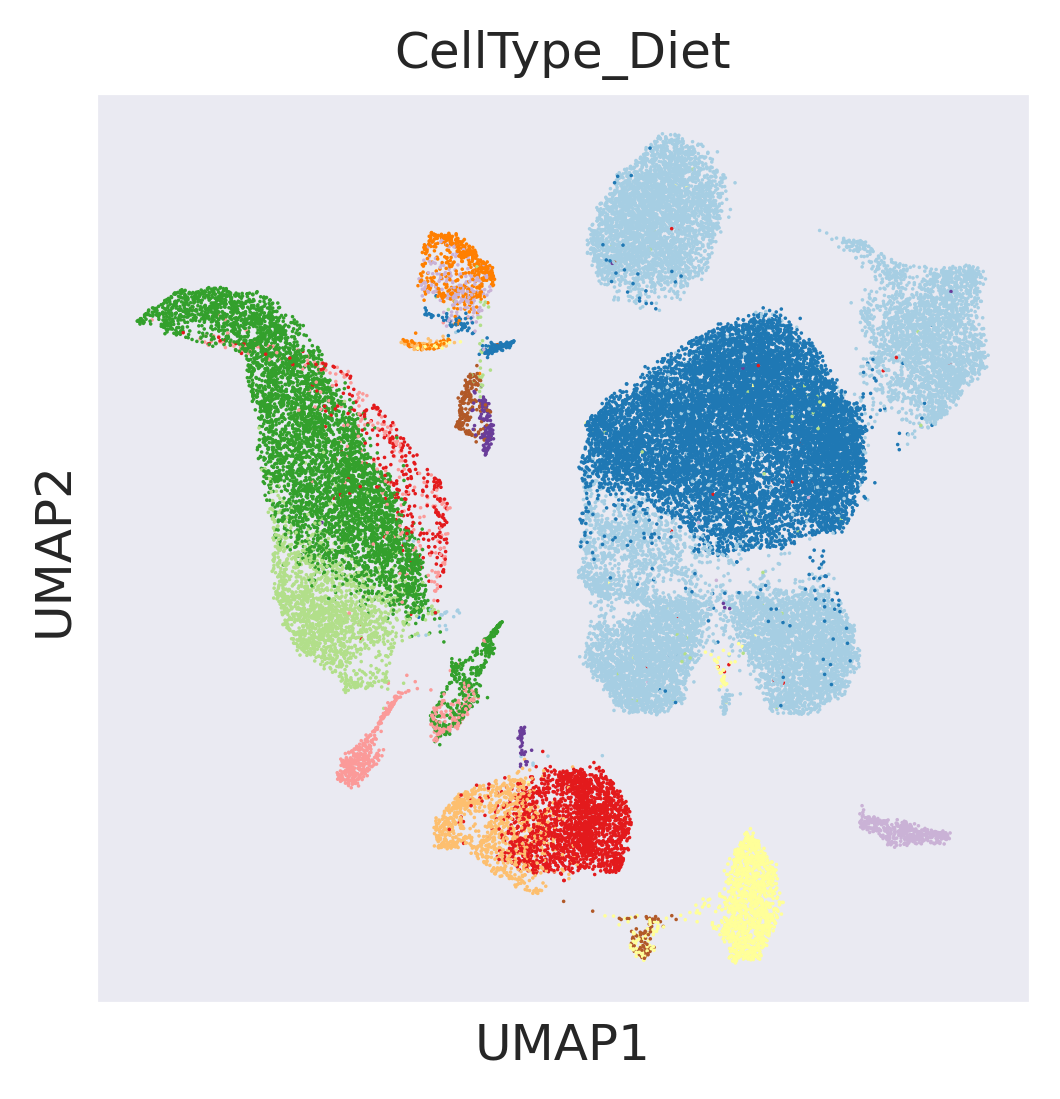

/usr/local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Figure size 600x600 with 0 Axes>

In [42]:
sc.pl.umap(latent_adata, color=["CellType_Diet"], frameon=True, palette="Paired", legend_loc=None, save='ColorfulUMAP_24W_Both')
import matplotlib.pyplot as plt

# Define which cell types (or CellType_Diet combos) to label
#selected_labels = ["Adipocytes_Brown_Control", "Macrophages_M2_HF", "ECs_Artery_Control"]
selected_labels = ['Adipocytes_Brown_Control', 'ECs_Cap_Control', 'Fibroblasts_Bmper+_Nrxn1+_Control', 'Adipocytes_3_Control', 'Pericytes_Control',
                  'Adipocytes_Brown_HF', 'ECs_Cap_HF', 'Fibroblasts_Bmper+_Nrxn1+_HF', 'Adipocytes_3_HF', 'Pericytes_HF']
# Compute UMAP if not already done
if "X_umap" not in latent_adata.obsm:
    sc.pp.neighbors(latent_adata)
    sc.tl.umap(latent_adata)

# Extract UMAP coordinates
umap_coords = latent_adata.obsm["X_umap"]
labels = latent_adata.obs["CellType_Diet"]

# Plot base figure
fig, ax = plt.subplots(figsize=(6, 6))
sc.pl.umap(latent_adata, color="diet", ax=ax, show=False, frameon=True, palette="Paired", save='DietUMAP_24W_Both') #legend_loc=None,) #, save="2A2.svg"

# Overlay text labels at the median position for each selected celltype_diet
for label in selected_labels:
    idx = labels == label
    if np.sum(idx) == 0:
        continue
    x = np.median(umap_coords[idx, 0])
    y = np.median(umap_coords[idx, 1])
    ax.text(x, y, label, fontsize=9, weight='bold', color='black', ha='center')

plt.tight_layout()
plt.show()


/usr/local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


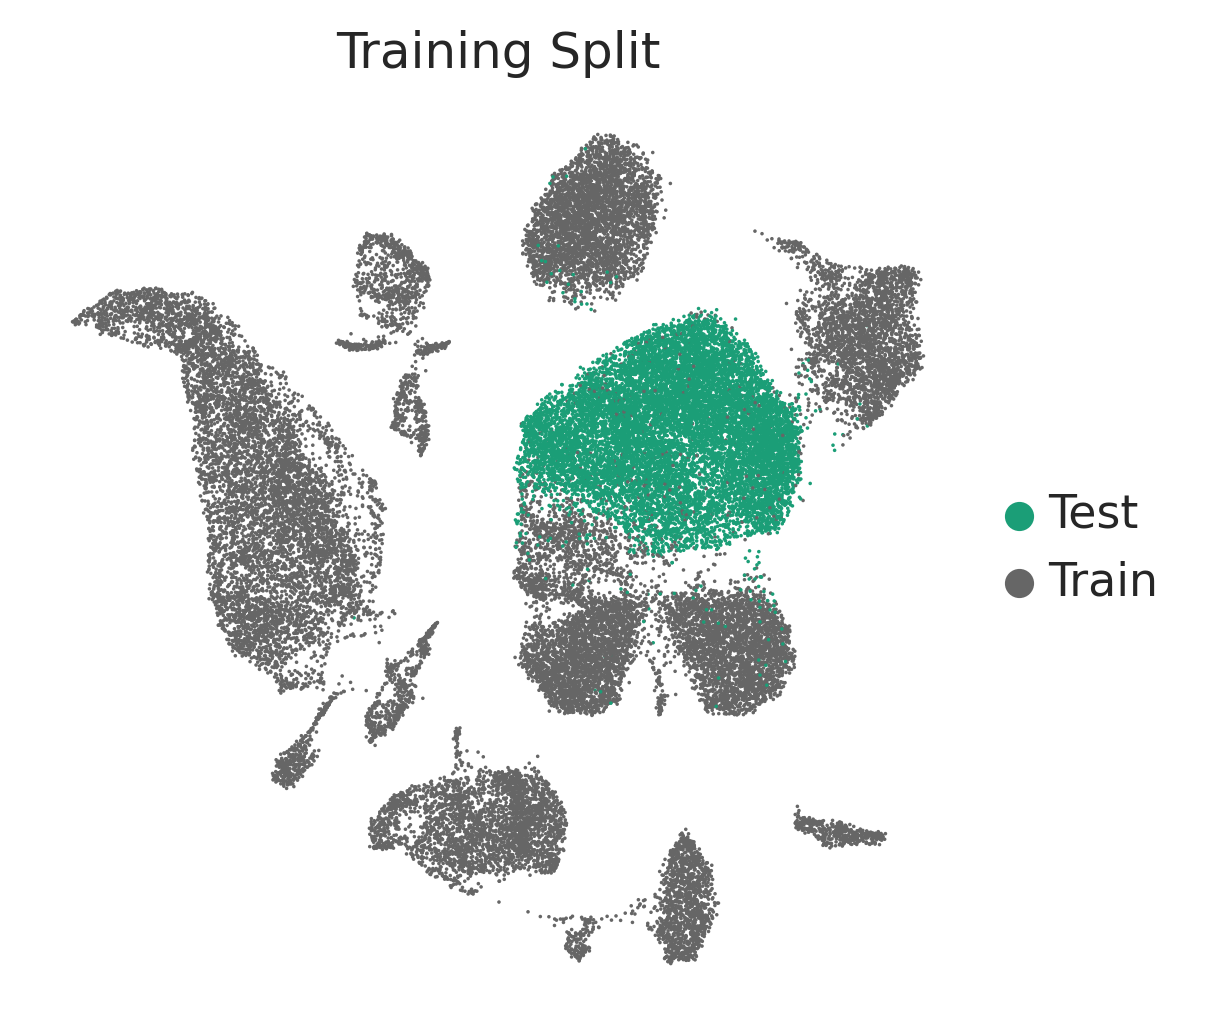

In [43]:
sc.pl.umap(latent_adata, color="Training Split", frameon=False, palette="Dark2", save='TrainTestUMAP_24W_Both') #, save ="2A1.svg"
 

## Figure 2B

In [44]:


# Prediction using your wrapped method
def model_predict(model, control_dose, treated_dose, test_celltype, dose_column_type, regression=True):
    pred, delta, *other = model.predict(
        ctrl_key=control_dose,
        treat_key=treated_dose,
        cell_type_to_predict=test_celltype,
        regression=regression
    )
    reg = other[0] if other else None

    pred.obs[condition_column_name] = treated_dose
    pred.obs[condition_column_name] = pred.obs[condition_column_name].astype(dose_column_type)
    pred.obs['diet'] = f'{treated_dose}'

    return {treated_dose: pred}, delta, reg

dose_column_type = adata.obs[condition_column_name].dtype

pred, delta, reg = model_predict(
    model=model,
    control_dose=control_dose,
    treated_dose=treated_dose,
    test_celltype=celltype_to_predict,
    dose_column_type=dose_column_type,
    regression=True
)

# Add 'diet' column to predicted cells
pred_adata = pred[treated_dose]
pred_adata.obs["diet"] = "pred"

# Filter real data for this celltype and relevant doses
ctrl_adata = adata[
    (adata.obs["celltype"] == celltype_to_predict) &
    (adata.obs["diet"] == control_dose)
].copy()

treat_adata = adata[
    (adata.obs["celltype"] == celltype_to_predict) &
    (adata.obs["diet"] == treated_dose)
].copy()

# Combine all into eval set
eval_adata = anndata.concat([ctrl_adata, treat_adata, pred_adata], join="inner")

# Add readable labels for treatment groups
eval_adata.obs["Treatment"] = eval_adata.obs["diet"].map({
    control_dose: "Control",
    treated_dose: "HF"
}).fillna("scVIDR")

print("Predicted adata shape:", pred_adata.shape)
print("Control cells:", ctrl_adata.shape)
print("Treated cells:", treat_adata.shape)
print("Eval adata shape:", eval_adata.shape)
print(eval_adata.obs["Treatment"].value_counts())
print(eval_adata.obs["diet"].unique())

# PCA + plotting
sc.tl.pca(eval_adata)




OKA????ASD?A
Sampling with RANDOM SAMPLING FUNCTION.


/usr/local/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/mnt/scratch/bowmand8/scVIDR/scvidr_sandbox/scVIDR/vidr/vidr.py:136: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  new_adata = ctrl_x.concatenate(treat_x)
/usr/local/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/usr/local/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/usr/local/lib/python3.9/site-packages/annda

INFO     Received view of anndata, making copy.                                                                    


INFO:scvi.model.base._base_model:Received view of anndata, making copy.


INFO     Input adata not setup with scvi. attempting to transfer anndata setup                                     


...

INFO     Successfully registered anndata object containing 133920 cells, 5000 vars, 2 batches, 28 labels, and 0    
         proteins. Also registered 0 extra categorical covariates and 0 extra continuous covariates.               


INFO:scvi.data._anndata:Successfully registered anndata object containing 133920 cells, 5000 vars, 2 batches, 28 labels, and 0 proteins. Also registered 0 extra categorical covariates and 0 extra continuous covariates.
/usr/local/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


STARTING REGRESSION ANALYSIS FOR Adipocytes_2
STARTING REGRESSION ANALYSIS FOR Adipocytes_3
STARTING REGRESSION ANALYSIS FOR B_Cells_Naive
STARTING REGRESSION ANALYSIS FOR Dendritic_Cells
STARTING REGRESSION ANALYSIS FOR Doublets
STARTING REGRESSION ANALYSIS FOR ECs_Artery
STARTING REGRESSION ANALYSIS FOR ECs_Cap
STARTING REGRESSION ANALYSIS FOR ECs_Lymph
STARTING REGRESSION ANALYSIS FOR ECs_Lymph_Piezo2+
STARTING REGRESSION ANALYSIS FOR ECs_Venous
STARTING REGRESSION ANALYSIS FOR ECs_Venous_Fbn1+
STARTING REGRESSION ANALYSIS FOR Fibroblasts_Bmper+
STARTING REGRESSION ANALYSIS FOR Fibroblasts_Bmper+_Nrxn1+
STARTING REGRESSION ANALYSIS FOR Fibroblasts_Pi16+
STARTING REGRESSION ANALYSIS FOR Fibroblasts_Pi16++
STARTING REGRESSION ANALYSIS FOR Macrophages_M1_Cd80+
STARTING REGRESSION ANALYSIS FOR Macrophages_M2
STARTING REGRESSION ANALYSIS FOR Macrophages_M2_F13a1+
STARTING REGRESSION ANALYSIS FOR Mesothelial_Cells
STARTING REGRESSION ANALYSIS FOR Monocytes
STARTING REGRESSION ANALYSIS FOR

/usr/local/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/usr/local/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Predicted adata shape: (2401, 5000)
Control cells: (10836, 5000)
Treated cells: (12370, 5000)
Eval adata shape: (25607, 5000)
HF         12370
Control    10836
scVIDR      2401
Name: Treatment, dtype: int64
['Control' 'HF' 'pred']


In [45]:
pred_adata

AnnData object with n_obs × n_vars = 2401 × 5000
    obs: 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'n_genes', 'scDblFinder_score', 'scDblFinder_class', 'Sample', 'tissue', 'diet', 'time', 'sex', 'batch', 'sample_type', 'rat_id', 'weight_3W', 'weight_10W', 'weight_17W', 'weight_24W', 'MAP_7W', 'systolic_bp_7W', 'MAP_9W', 'systolic_bp_9W', 'MAP_16W', 'systolic_bp_16W', 'MAP_24W', 'systolic_bp_24W', 'doublet', 'celltype', 'celltype_broad', '_scvi_batch', '_scvi_labels', '_scvi_local_l_mean', '_scvi_local_l_var'
    var: 'gene_ids', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_vari

In [46]:
eval_adata.obs['sex'].unique()

['M', 'F']
Categories (2, object): ['F', 'M']

... storing 'diet' as categorical
... storing 'Treatment' as categorical
/usr/local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


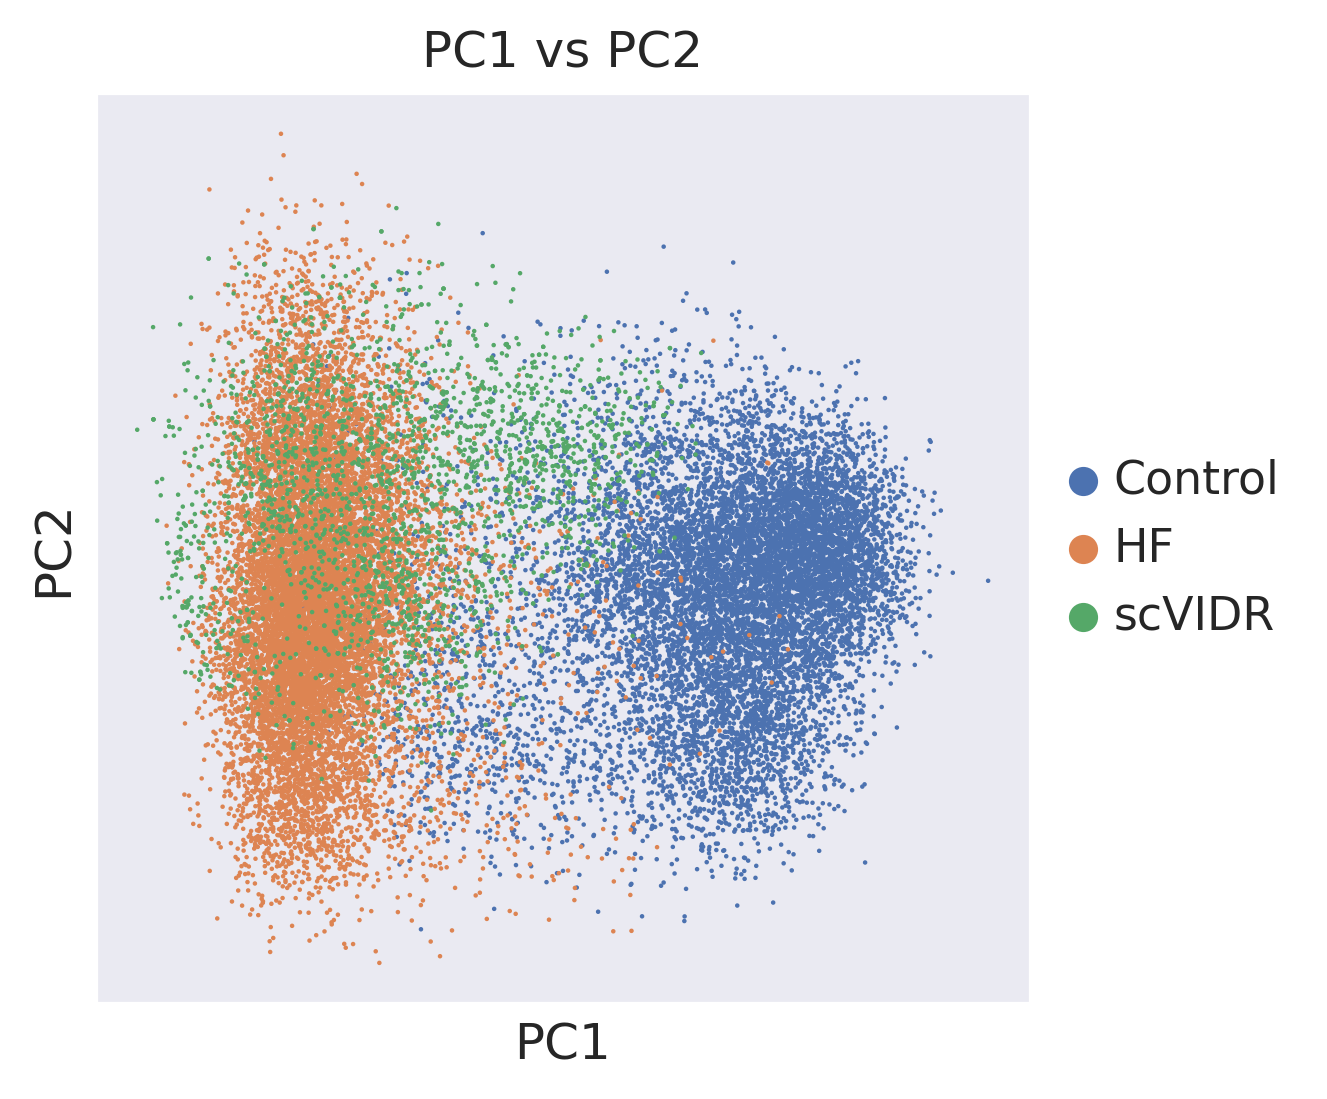

/usr/local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


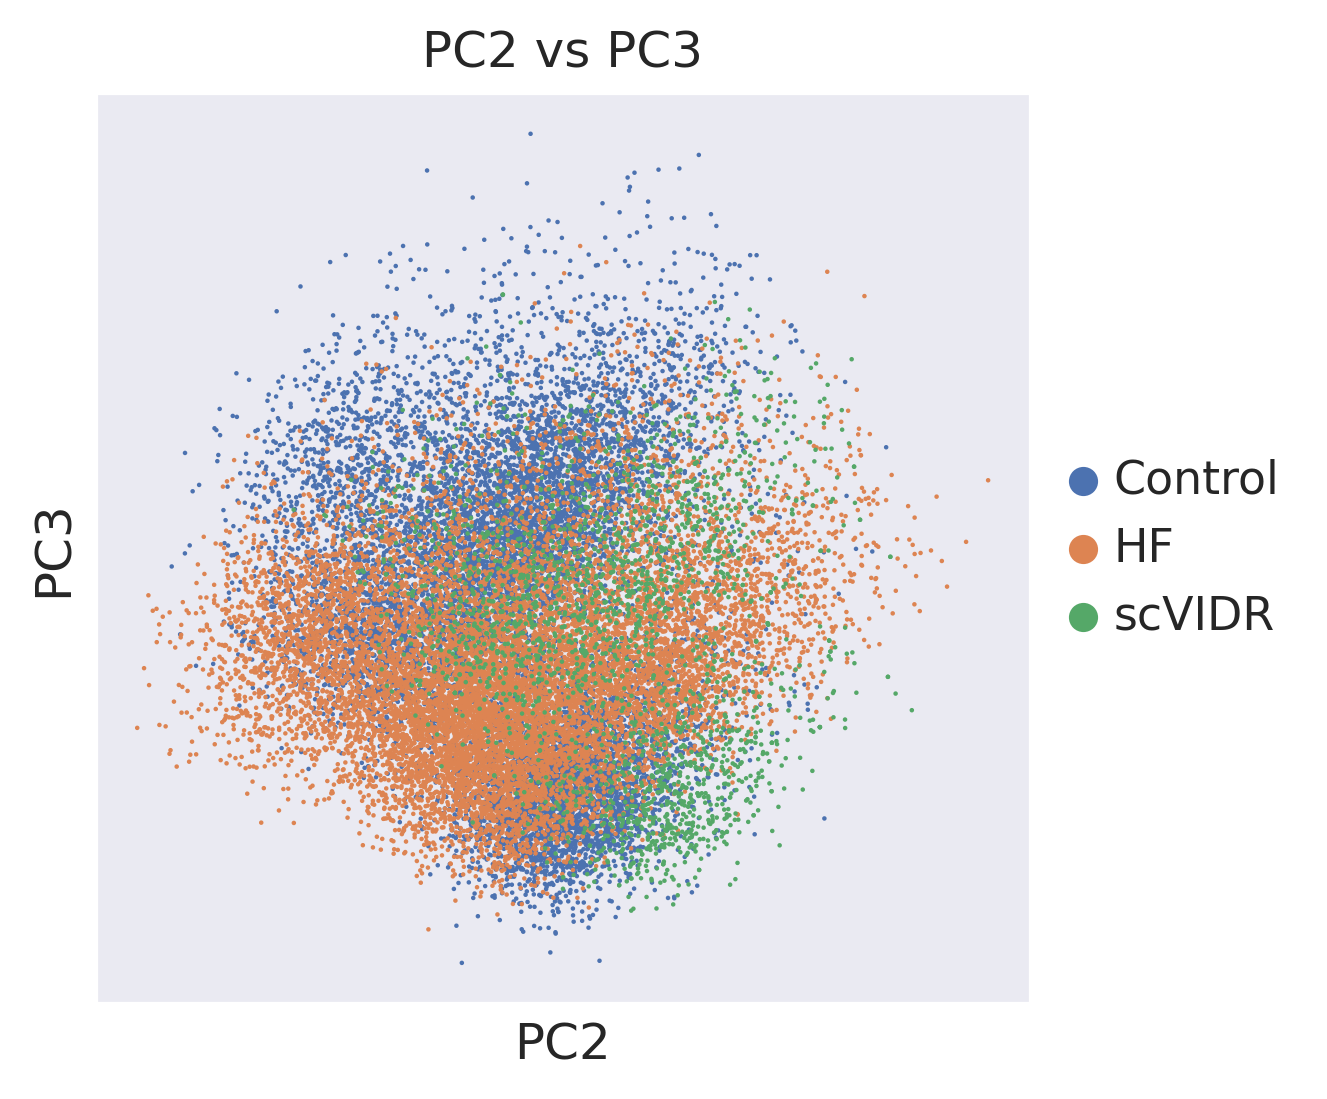

/usr/local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


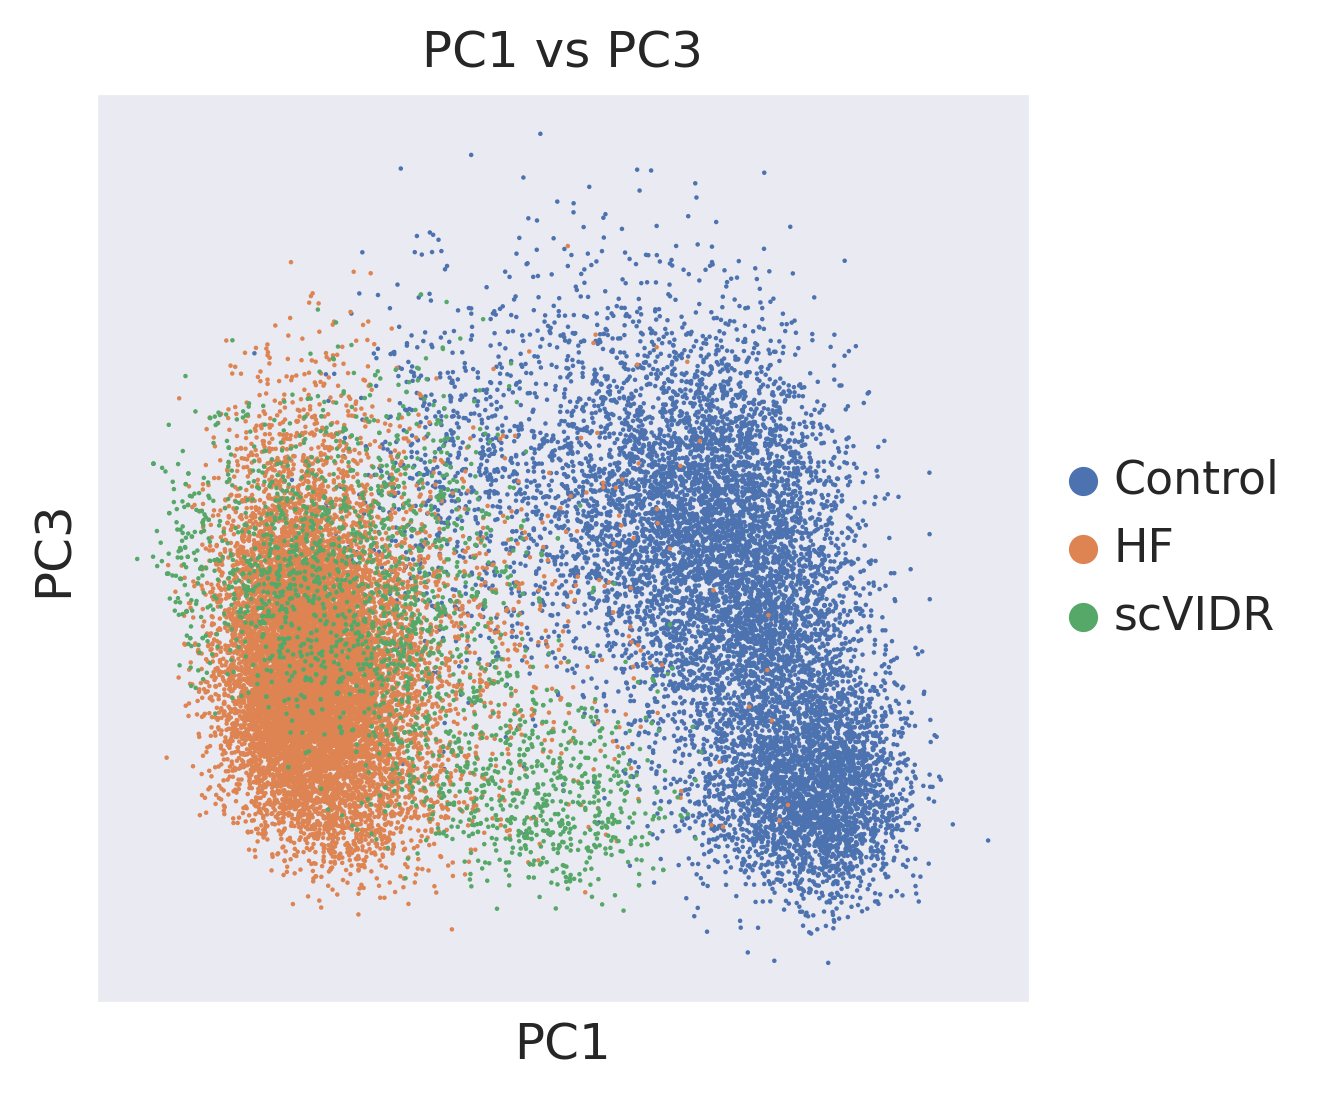

In [47]:
# Plot PC1 vs PC2 (default)
sc.pl.pca(eval_adata, color="Treatment", frameon=True, title="PC1 vs PC2", components="1,2", show=True)

# Plot PC2 vs PC3
sc.pl.pca(eval_adata, color="Treatment", frameon=True, title="PC2 vs PC3", components="2,3", show=True)

# Plot PC1 vs PC3
sc.pl.pca(eval_adata, color="Treatment", frameon=True, title="PC1 vs PC3", components="1,3", show=True)


/usr/local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


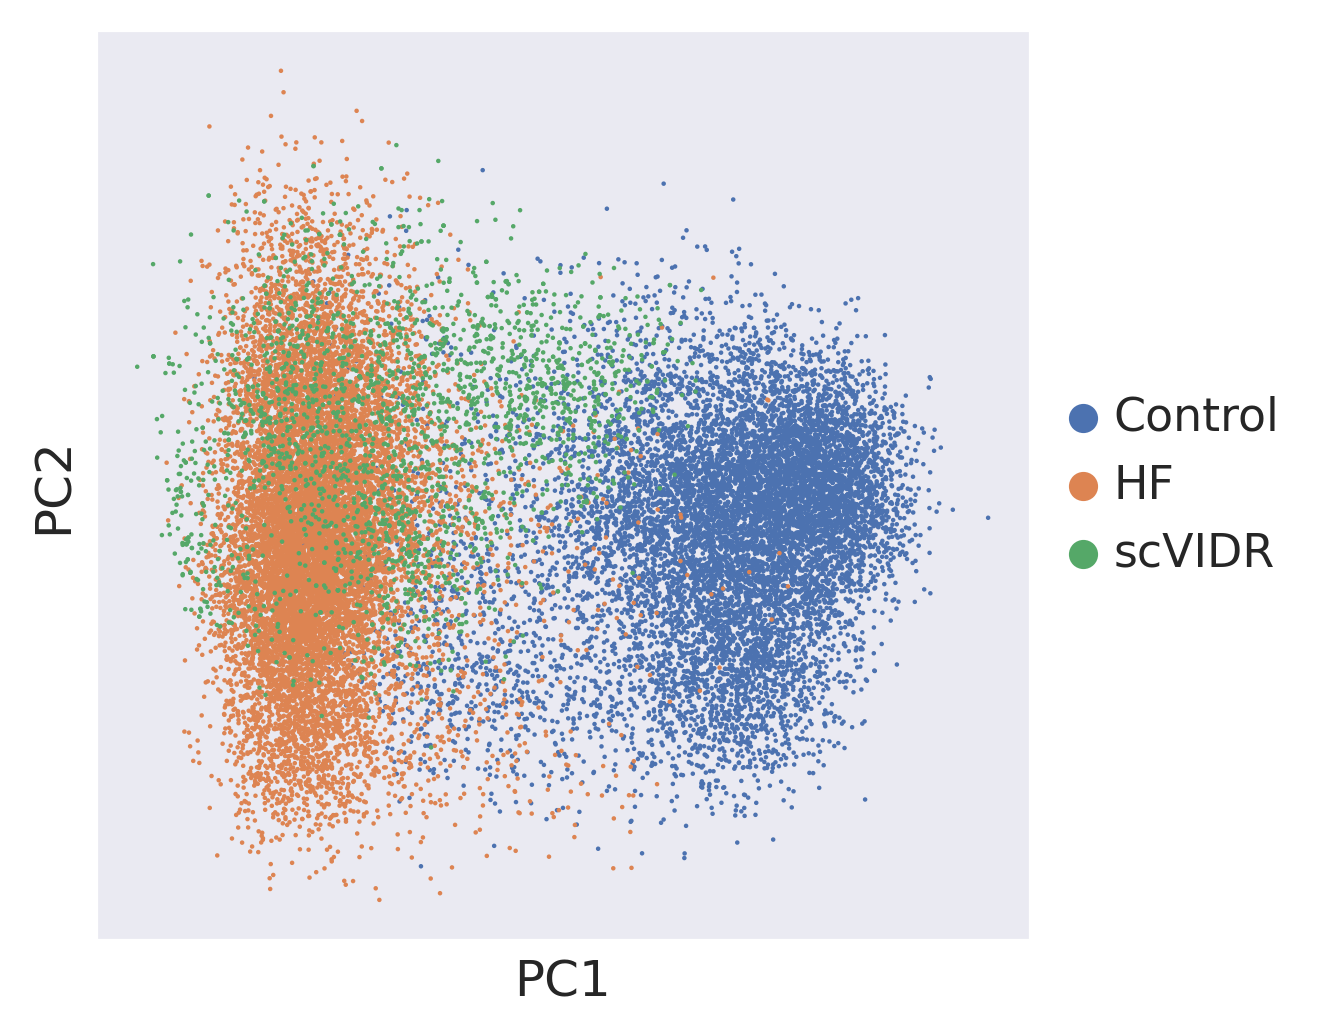

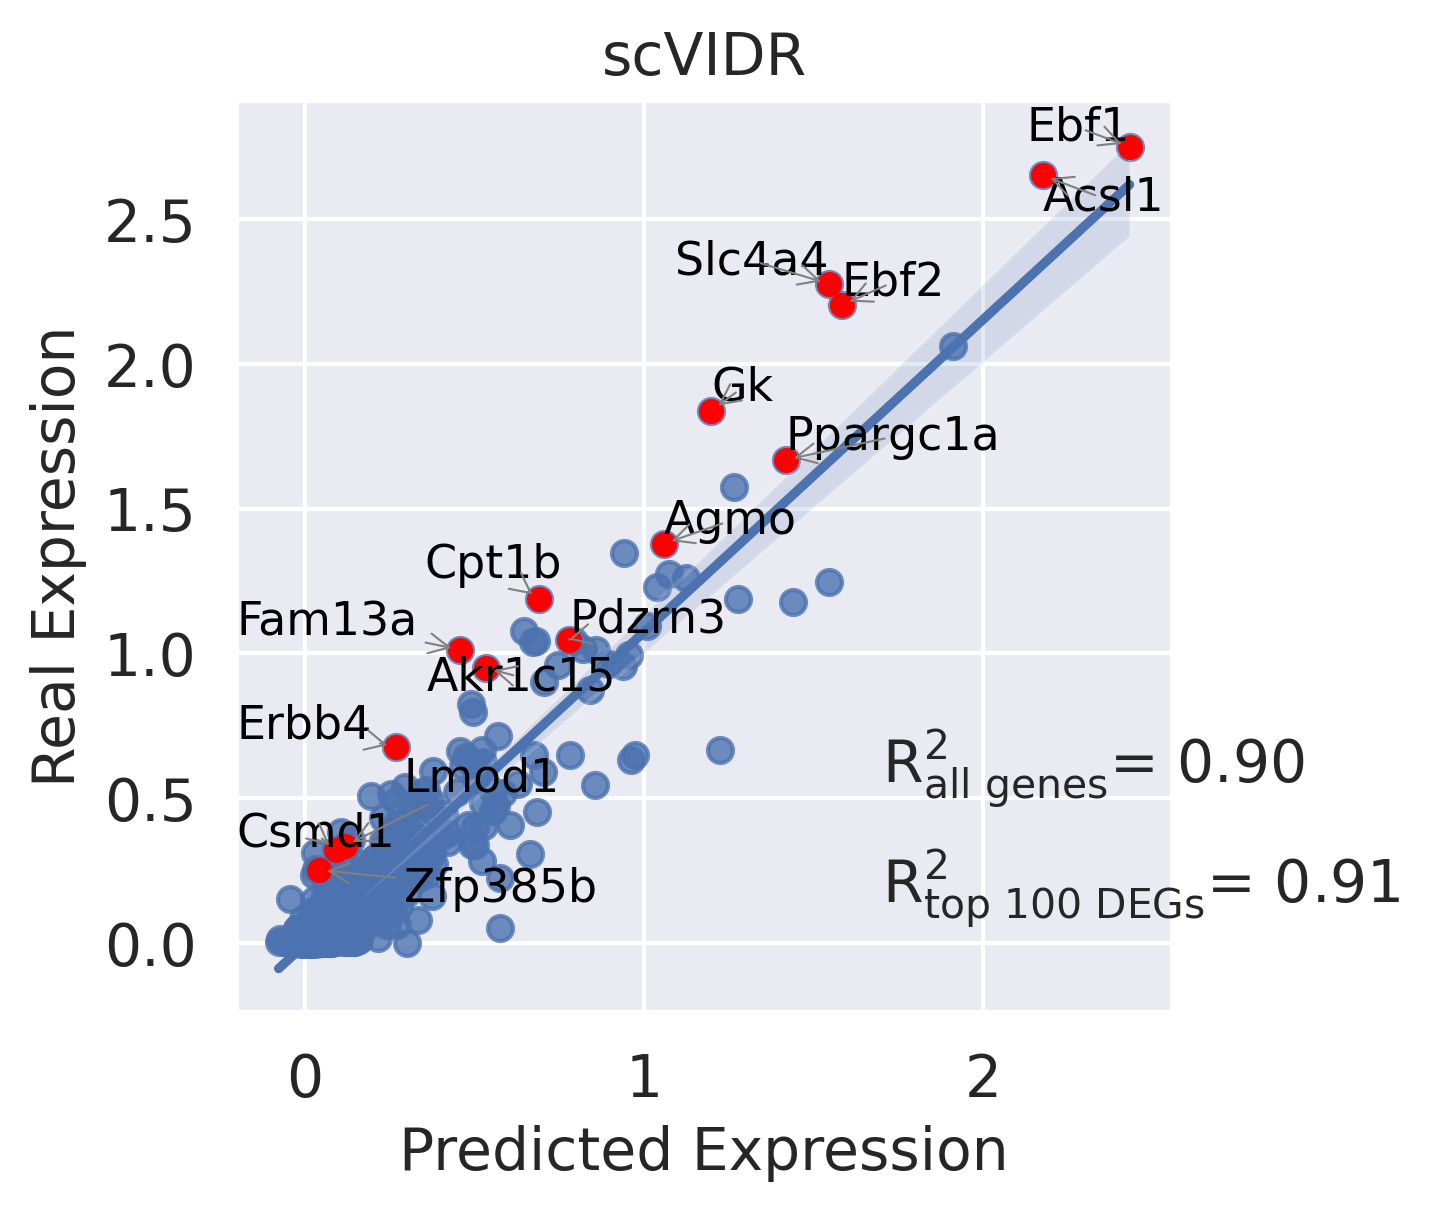

R² values: (0.898531888947546, 0.914708569134487)


In [48]:
sc.pl.pca(eval_adata, color="Treatment", frameon=True, title="", show=True, save='PCA_LatentSpace_24W_Both') #save="2C1.svg"
# DEG analysis on real cells only
real_adata = adata[
    (adata.obs["celltype"] == celltype_to_predict) &
    (adata.obs["diet"].isin([control_dose, treated_dose]))
].copy()

sc.tl.rank_genes_groups(real_adata, groupby="diet", method="wilcoxon")
diff_genes = real_adata.uns["rank_genes_groups"]["names"][treated_dose]

# Plot predicted vs real gene expression using reg_mean_plot
r2_value = model.reg_mean_plot(
    eval_adata,
    axis_keys={"x": "pred", "y": treated_dose},
    gene_list=diff_genes[:15],
    top_100_genes=diff_genes[:100],
    labels={"x": "Predicted Expression", "y": "Real Expression"},
    path_to_save="../figures/Regression_24W_Both",
 
    show=True,
    legend=False,
    title="scVIDR"
)

print("R² values:", r2_value)

In [49]:
raise ValueError('Stop here.')

ValueError: Stop here.